In [38]:
%matplotlib widget
import os
import re
from collections import defaultdict
from pathlib import Path
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# 1. STYLE CONFIGURATION
# ============================================================

poster_style = {
    "figsize": (3, 3),
    "dpi": 300,
    "font_size": 10,
    "title_size": 12,
    "label_size": 12,
    "legend_size": 8,
    "line_width": 2,
    "font_family": "Calibri",
    "grid": False,               
    "colors": ["#0072B2", "#E69F00", "#009E73", "#CC79A7", "#56B4E9", "#D55E00", "#F0E442"], 
    "linestyles": ["-", "--", "-.", ":"]
}

# ============================================================
# 2. LOAD RAMAN TXT SPECTRA & GROUP THEM
# ============================================================

target_dirs = [
    r"H:\FUBerlin\Measurements\Raman Xplora\CristianB\20260218_Ram_CNT_dispersions",
    r"H:\FUBerlin\Measurements\Raman Xplora\CristianB\20260220_Ram_CNT_dispersions",
    r"H:\FUBerlin\Measurements\Raman Xplora\CristianB\20260313_Ram_CNT_DGU_fractions",
    r"H:\FUBerlin\Measurements\Raman Xplora\CristianB\20260402_CNT_F005_6FBz@P2",
    r"H:\FUBerlin\Measurements\Raman Xplora\CristianB\20260529_CNT_F005_6FBz@P2_phDADQ_6FBz_P2Ref@P2",
    r"H:\FUBerlin\Measurements\Raman Xplora\CristianB\20260605_CNT_F005_6FBz@P2_F006_phDADQ@P2",
    r"H:\FUBerlin\Measurements\Raman Xplora\CristianB\20260807_FilledCNTs_PostDGU_P2_F005LP_F006WA_F007WA",
]

raman_spectra = {}

# Dictionary to hold the grouped filenames for printing
# Structure: { "FolderName": { "532 nm": ["file1.txt", ...], ... } }
grouped_files = defaultdict(lambda: defaultdict(list))

for folder in target_dirs:
    folder_name = os.path.basename(folder)
    print(f"Reading folder: {folder_name} ...")
    
    for root, dirs, files in os.walk(folder):
        for file in files:
            if not file.lower().endswith(".txt"):
                continue
            
            path = os.path.join(root, file)
            
            # Extract wavelength using regex (looks for 3 or 4 digits followed by 'nm', ignoring spaces)
            wl_match = re.search(r'(\d{3,4}\s*nm)', file, re.IGNORECASE)
            wavelength = wl_match.group(1).lower() if wl_match else "Unknown_Wavelength"
            
            try:
                df = pd.read_csv(
                    path, 
                    sep="\t", 
                    comment="#", 
                    header=None, 
                    encoding="latin1",
                    usecols=[0, 1] 
                )
                
                df.columns = ["RamanShift", "Intensity"]
                df["RamanShift"] = pd.to_numeric(df["RamanShift"], errors="coerce")
                df["Intensity"] = pd.to_numeric(df["Intensity"], errors="coerce")
                df = df.dropna().sort_values("RamanShift").reset_index(drop=True)
                
                raman_spectra[file] = df
                grouped_files[folder_name][wavelength].append(file)
                
            except Exception as e:
                print(f"  [ERROR] Could not load {file}: {e}")

# --- PRINT THE FORMATTED LISTS ---
print("\n\n" + "="*70)
print(" AVAILABLE SPECTRA (Ready to copy-paste!)")
print("="*70)

for fld, wl_dict in grouped_files.items():
    for wl, file_list in wl_dict.items():
        # Create a valid python variable name (e.g., Spec_532nm_20260218_Ram...)
        clean_wl = wl.replace(" ", "")
        var_name = f"Spec_{clean_wl}_{fld}"
        
        print(f"\n# Spectra from folder: {fld} | Wavelength: {wl}")
        print(f"{var_name} = [")
        
        # Sorting alphabetically naturally groups them by grating and sample name!
        for name in sorted(file_list):
            print(f'    "{name}",')
        print("]")


# ============================================================
# 4. TRIM SPECTRA (Make regions equal)
# ============================================================

def TrimSpectra(spectra_input, xmin, xmax):
    trimmed = {}
    for name, df in spectra_input.items():
        mask = (df["RamanShift"] >= xmin) & (df["RamanShift"] <= xmax)
        trimmed[name] = df[mask].copy().reset_index(drop=True)
        # print(f"Trimmed {name} to {xmin}-{xmax} cm-1") # Commented out to reduce console spam
    return trimmed


# ============================================================
# 5. NORMALIZATION FUNCTION
# ============================================================

def NormalizeSpectra(spectra_input, xmin=None, xmax=None, mode="M"):
    normalized = {}
    for name, df in spectra_input.items():
        df_norm = df.copy()
        
        X = df_norm["RamanShift"].values
        Y = df_norm["Intensity"].values
        
        if xmin is not None and xmax is not None:
            mask = (X >= xmin) & (X <= xmax)
        else:
            mask = np.ones_like(X, dtype=bool)
            
        X_window = X[mask]
        Y_window = Y[mask]
        
        if len(X_window) == 0:
            print(f"WARNING: No points in normalization range for {name}")
            continue
            
        if mode.upper() == "M":
            factor = np.max(Y_window)
        elif mode.upper() == "I":
            factor = np.trapezoid(Y_window, X_window)
        elif mode.upper() == "V":
            factor = np.min(Y_window)
        else:
            raise ValueError("Mode must be 'M', 'I', or 'V'")
            
        if factor == 0:
            continue
            
        df_norm["Intensity"] = Y / factor
        normalized[name] = df_norm
        
    return normalized

# ============================================================
# 6. PLOT FUNCTION
# ============================================================

def PlotRaman(spectra_dict, spectra_names, style=poster_style, offset_step=0.0, 
              xmin=None, xmax=None, ymin=None, ymax=None, 
              custom_labels=None):
    
    plt.figure(figsize=style["figsize"], dpi=style["dpi"])
    plt.rcParams.update({
        "font.size": style["font_size"],
        "font.family": style["font_family"]
    })
    
    colors = style.get("colors")
    
    for i, name in enumerate(spectra_names):
        if name not in spectra_dict:
            print(f"WARNING: {name} not found in dictionary")
            continue
            
        df = spectra_dict[name]
        label = custom_labels[i] if custom_labels and i < len(custom_labels) else name
        
        X = df["RamanShift"].values
        Y = df["Intensity"].values + (i * offset_step)
        
        c = colors[i % len(colors)] if colors else None
        
        plt.plot(X, Y, label=label, linewidth=style["line_width"], color=c)

    plt.xlabel("Raman shift (cm$^{-1}$)", fontsize=style["label_size"])
    plt.ylabel("Intensity (a.u.)", fontsize=style["label_size"])
    #plt.title("Raman Spectra", fontsize=style["title_size"])
    
    if xmin is not None or xmax is not None:
        plt.xlim(xmin, xmax)
    if ymin is not None or ymax is not None:
        plt.ylim(ymin, ymax)
        
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=style["legend_size"])
    plt.tight_layout()
    plt.show()

# ============================================================
# 3. SELECT YOUR EXPERIMENTAL SPECTRA
# ============================================================

# Paste your copied lists from the console output right here!
# Example:
# Spec_532nm_20260218 = [ ... ]

selected_list = [] # <-- PUT THE LIST YOU WANT TO PLOT HERE

# 1. Grab actual dataframes
selected_spectra_dict = {
    name: raman_spectra[name] 
    for name in selected_list 
    if name in raman_spectra
}

Reading folder: 20260218_Ram_CNT_dispersions ...
  [ERROR] Could not load README.txt: Usecols do not match columns, columns expected but not found: [1]
Reading folder: 20260220_Ram_CNT_dispersions ...
  [ERROR] Could not load README.txt: Usecols do not match columns, columns expected but not found: [1]
Reading folder: 20260313_Ram_CNT_DGU_fractions ...
  [ERROR] Could not load file_list.txt: Usecols do not match columns, columns expected but not found: [1]
  [ERROR] Could not load README.txt: Usecols do not match columns, columns expected but not found: [1]
Reading folder: 20260402_CNT_F005_6FBz@P2 ...
  [ERROR] Could not load README.txt: Usecols do not match columns, columns expected but not found: [1]
Reading folder: 20260529_CNT_F005_6FBz@P2_phDADQ_6FBz_P2Ref@P2 ...
Reading folder: 20260605_CNT_F005_6FBz@P2_F006_phDADQ@P2 ...
  [ERROR] Could not load README.txt: Usecols do not match columns, columns expected but not found: [1]
  [ERROR] Could not load file_list.txt: Usecols do not m

In [39]:
# Spectra from folder: 20260220_Ram_CNT_dispersions | Wavelength: 532 nm
Spec_532nm_20260220_Ram_CNT_dispersions = [
    #"NanIn_BS_RBM___532 nm_2400gr_x10_2_120 s_1%.txt",
    #"NanIn_TS_RBM___532 nm_2400gr_x10_2_120 s_1%_1.txt",
    #"NoPo_TS_RBM___532 nm_2400gr_x10_2_120 s_1%.txt",
    #"P2_TS_RBM___532 nm_2400gr_x10_2_120 s_1%.txt",
]

# Spectra from folder: 20260313_Ram_CNT_DGU_fractions | Wavelength: 638 nm
Spec_638nm_20260313_Ram_CNT_DGU_fractions = [
    #"DGU_NoPo_4E_638 nm_2400gr_x50_2_120 s_10%.txt",
    #"DGU_NoPo_4E_638 nm_2400gr_x50_2_60 s_10%.txt",
    #"DGU_P2_1A_638 nm_2400gr_x10_3_30 s_1%_1.txt",
    #"QuartzCell_638 nm_2400gr_x10_3_30 s_1%.txt",
]

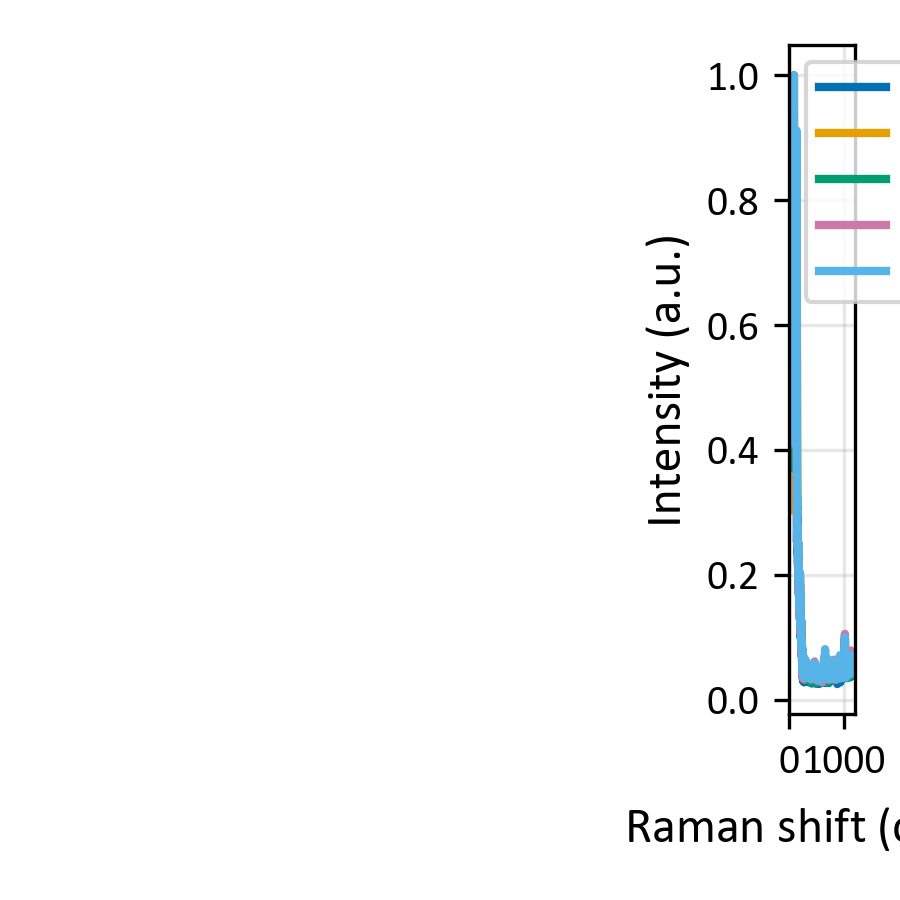

In [40]:
# Spectra from folder: 20260807_FilledCNTs_PostDGU_P2_F005LP_F006WA_F007WA | Wavelength: 785 nm
Spec_785nm_20260807_FilledCNTs_PostDGU_P2_F005LP_F006WA_F007WA = [
    "260807_F005LP_6FBz@P2_DGUdial_785 nm_1200gr_x10_0_1%_3_120_50_100_sc590.txt",
    "260807_F006WA_phDADQ@P2_DGUdial_785 nm_1200gr_x10_0_1%_3_120_50_100_sc590.txt",
    "260807_F007WA_1BrC18@P2_DGUdial_785 nm_1200gr_x10_0_1%_3_120_50_100_sc590.txt",
    "260807_P2_DGUdialAgain_785 nm_1200gr_x10_0_1%_3_120_50_100_sc590.txt",
    "260807_P2_DGUdial_785 nm_1200gr_x10_0_1%_3_120_50_100_sc590.txt",
]

selected_spectra = Spec_785nm_20260807_FilledCNTs_PostDGU_P2_F005LP_F006WA_F007WA
selected_spectra = {name: raman_spectra[name] for name in selected_spectra if name in raman_spectra}
#selected_spectra = TrimSpectra(selected_spectra, xmin=800, xmax=2000)
selected_spectra = NormalizeSpectra(selected_spectra, xmin=0, xmax=10000, mode="M")


# Optional: Provide cleaner names for the legend based on the filenames
clean_labels = [
 
]

# Plot the final processed data
PlotRaman(
    spectra_dict=selected_spectra, 
    spectra_names=selected_spectra,
    custom_labels=None,
    offset_step=0.0,          # Shifts each spectrum up by 1.2 for easy stacking
    xmin=None,
    xmax=None,
    #ymax=50
)

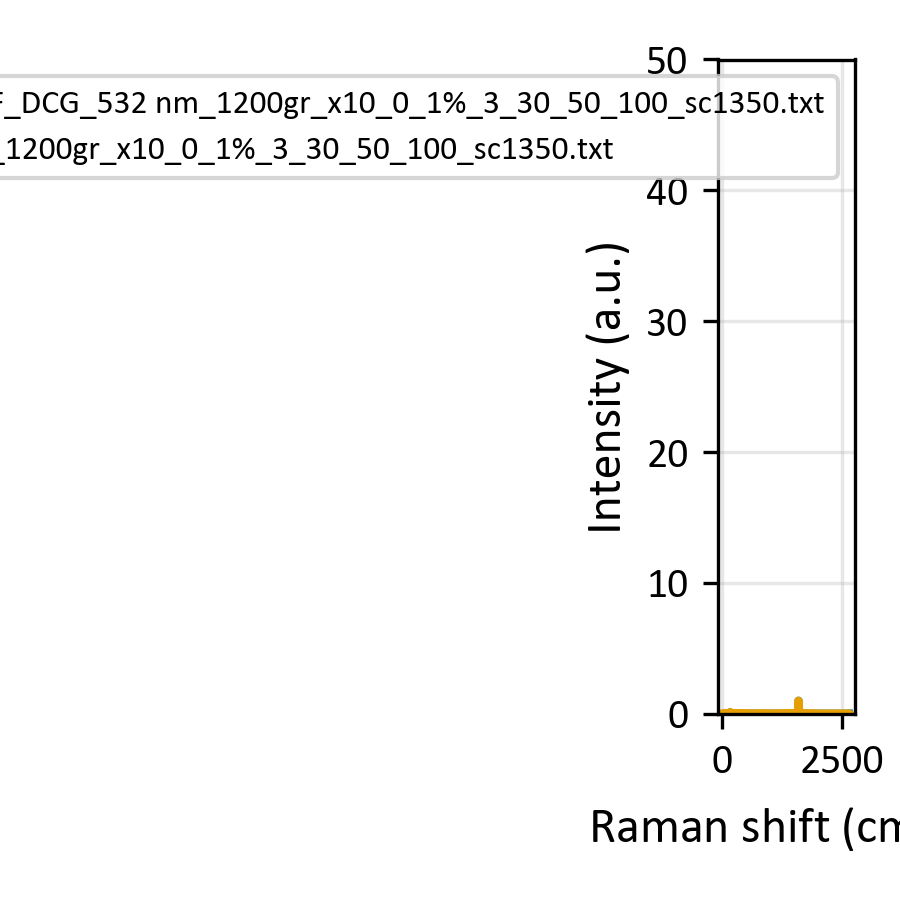

In [41]:
# Spectra from folder: 20260807_FilledCNTs_PostDGU_P2_F005LP_F006WA_F007WA | Wavelength: 532 nm
Spec_532nm_20260807_FilledCNTs_PostDGU_P2_F005LP_F006WA_F007WA = [
    "260807_F007_1BrC18@P2_CF_DCG_532 nm_1200gr_x10_0_1%_3_30_50_100_sc1350.txt",
    "260807_P2_CF_DCG_532 nm_1200gr_x10_0_1%_3_30_50_100_sc1350.txt",
]

selected_spectra = Spec_532nm_20260807_FilledCNTs_PostDGU_P2_F005LP_F006WA_F007WA
selected_spectra = {name: raman_spectra[name] for name in selected_spectra if name in raman_spectra}
#selected_spectra = TrimSpectra(selected_spectra, xmin=800, xmax=2000)
selected_spectra = NormalizeSpectra(selected_spectra, xmin=0, xmax=10000, mode="M")


# Optional: Provide cleaner names for the legend based on the filenames
clean_labels = [
 
]

# Plot the final processed data
PlotRaman(
    spectra_dict=selected_spectra, 
    spectra_names=selected_spectra,
    custom_labels=None,
    offset_step=0.0,          # Shifts each spectrum up by 1.2 for easy stacking
    xmin=None,
    xmax=None,
    ymax=50
)

C:\Users\cborja\AppData\Local\Temp\ipykernel_19608\3068673424.py:201: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


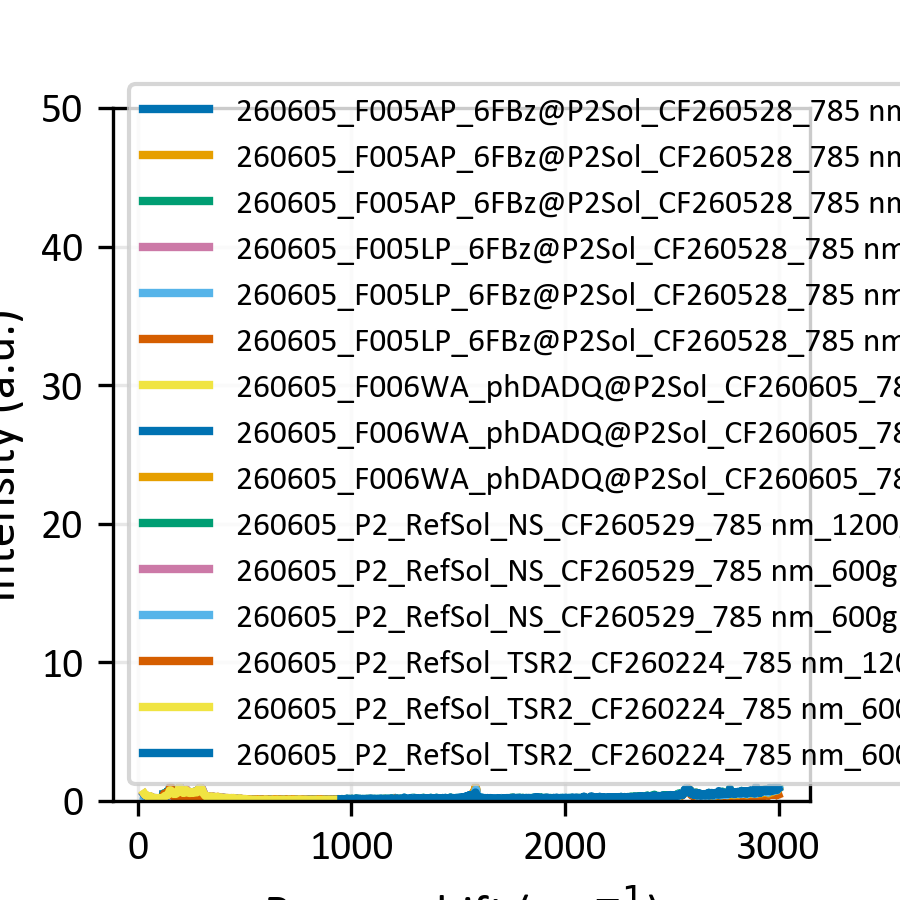

In [42]:
# Spectra from folder: 20260605_CNT_F005_6FBz@P2_F006_phDADQ@P2 | Wavelength: 785 nm
Spec_785nm_20260605_CNT_F005_6FBzP2_F006_phDADQP2 = [
    "260605_F005AP_6FBz@P2Sol_CF260528_785 nm_1200gr_x10_1%_5_30_50_100_sc650.txt",
    "260605_F005AP_6FBz@P2Sol_CF260528_785 nm_600gr_x10_0_1%_5_60_50_100_sc1250.txt",
    "260605_F005AP_6FBz@P2Sol_CF260528_785 nm_600gr_x10_0_1%_5_60_50_100_sc2000.txt",
    "260605_F005LP_6FBz@P2Sol_CF260528_785 nm_1200gr_x10_1%_5_30_50_100_sc650.txt",
    "260605_F005LP_6FBz@P2Sol_CF260528_785 nm_600gr_x10_0_1%_5_60_50_100_sc1250.txt",
    "260605_F005LP_6FBz@P2Sol_CF260528_785 nm_600gr_x10_0_1%_5_60_50_100_sc2000.txt",
    "260605_F006WA_phDADQ@P2Sol_CF260605_785 nm_1200gr_x10_1%_5_30_50_100_sc650.txt",
    "260605_F006WA_phDADQ@P2Sol_CF260605_785 nm_600gr_x10_0_1%_5_60_50_100_sc1250.txt",
    "260605_F006WA_phDADQ@P2Sol_CF260605_785 nm_600gr_x10_0_1%_5_60_50_100_sc2000.txt",
    "260605_P2_RefSol_NS_CF260529_785 nm_1200gr_x10_1%_5_30_50_100_sc650.txt",
    "260605_P2_RefSol_NS_CF260529_785 nm_600gr_x10_0_1%_5_60_50_100_sc1250.txt",
    "260605_P2_RefSol_NS_CF260529_785 nm_600gr_x10_0_1%_5_60_50_100_sc2000.txt",
    "260605_P2_RefSol_TSR2_CF260224_785 nm_1200gr_x10_1%_5_30_50_100_sc650.txt",
    "260605_P2_RefSol_TSR2_CF260224_785 nm_600gr_x10_0_1%_5_60_50_100_sc1250.txt",
    "260605_P2_RefSol_TSR2_CF260224_785 nm_600gr_x10_0_1%_5_60_50_100_sc2000.txt",
]
selected_spectra = Spec_785nm_20260605_CNT_F005_6FBzP2_F006_phDADQP2
selected_spectra = {name: raman_spectra[name] for name in selected_spectra if name in raman_spectra}
#selected_spectra = TrimSpectra(selected_spectra, xmin=800, xmax=2000)
selected_spectra = NormalizeSpectra(selected_spectra, xmin=0, xmax=10000, mode="M")


# Optional: Provide cleaner names for the legend based on the filenames
clean_labels = [
 
]

# Plot the final processed data
PlotRaman(
    spectra_dict=selected_spectra, 
    spectra_names=selected_spectra,
    custom_labels=None,
    offset_step=0.0,          # Shifts each spectrum up by 1.2 for easy stacking
    xmin=None,
    xmax=None,
    ymax=50
)

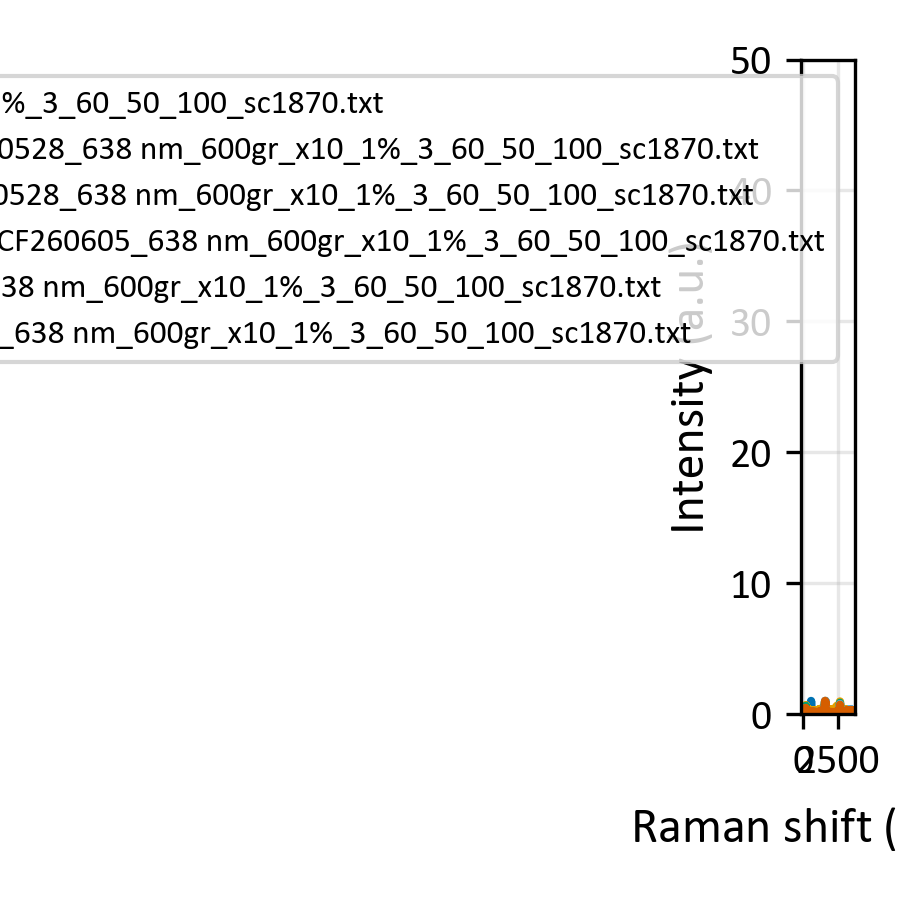

In [43]:
# Spectra from folder: 20260605_CNT_F005_6FBz@P2_F006_phDADQ@P2 | Wavelength: 638 nm
Spec_638nm_20260605_CNT_F005_6FBzP2_F006_phDADQP2 = [
    "260605_6FBz_638 nm_600gr_x10_1%_3_60_50_100_sc1870.txt",
    "260605_F005AP_6FBz@P2Sol_CF260528_638 nm_600gr_x10_1%_3_60_50_100_sc1870.txt",
    "260605_F005LP_6FBz@P2Sol_CF260528_638 nm_600gr_x10_1%_3_60_50_100_sc1870.txt",
    "260605_F006WA_phDADQ@P2Sol_CF260605_638 nm_600gr_x10_1%_3_60_50_100_sc1870.txt",
    "260605_P2_RefSol_NS_CF260529_638 nm_600gr_x10_1%_3_60_50_100_sc1870.txt",
    "260605_P2_RefSol_TSR2_CF260224_638 nm_600gr_x10_1%_3_60_50_100_sc1870.txt",
]


selected_spectra = Spec_638nm_20260605_CNT_F005_6FBzP2_F006_phDADQP2
selected_spectra = {name: raman_spectra[name] for name in selected_spectra if name in raman_spectra}
#selected_spectra = TrimSpectra(selected_spectra, xmin=800, xmax=2000)
selected_spectra = NormalizeSpectra(selected_spectra, xmin=0, xmax=10000, mode="M")


# Optional: Provide cleaner names for the legend based on the filenames
clean_labels = [
 
]

# Plot the final processed data
PlotRaman(
    spectra_dict=selected_spectra, 
    spectra_names=selected_spectra,
    custom_labels=None,
    offset_step=0.0,          # Shifts each spectrum up by 1.2 for easy stacking
    xmin=None,
    xmax=None,
    ymax=50
)

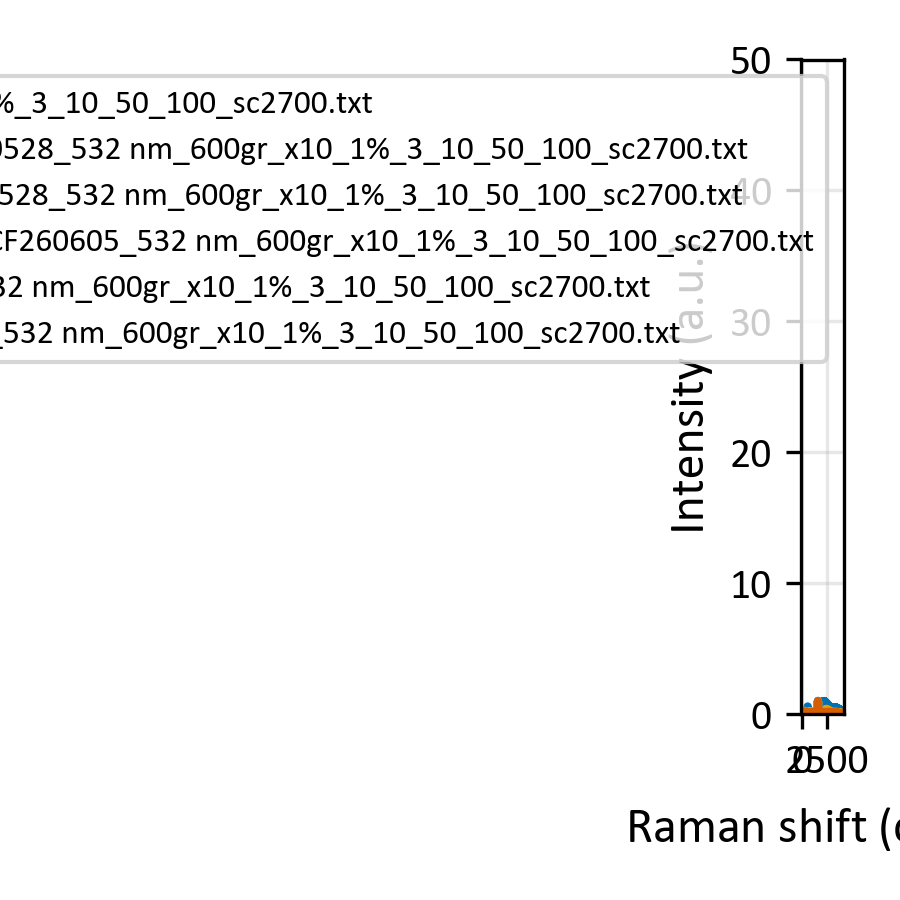

In [44]:
# Spectra from folder: 20260605_CNT_F005_6FBz@P2_F006_phDADQ@P2 | Wavelength: 532 nm
Spec_532nm_20260605_CNT_F005_6FBzP2_F006_phDADQP2 = [
    "260605_6FBz_532 nm_600gr_x10_1%_3_10_50_100_sc2700.txt",
    "260605_F005AP_6FBz@P2Sol_CF260528_532 nm_600gr_x10_1%_3_10_50_100_sc2700.txt",
    "260605_F005LP_6FBz@P2Sol_CF260528_532 nm_600gr_x10_1%_3_10_50_100_sc2700.txt",
    "260605_F006WA_phDADQ@P2Sol_CF260605_532 nm_600gr_x10_1%_3_10_50_100_sc2700.txt",
    "260605_P2_RefSol_NS_CF260529_532 nm_600gr_x10_1%_3_10_50_100_sc2700.txt",
    "260605_P2_RefSol_TSR2_CF260224_532 nm_600gr_x10_1%_3_10_50_100_sc2700.txt",
]

selected_spectra = Spec_532nm_20260605_CNT_F005_6FBzP2_F006_phDADQP2
selected_spectra = {name: raman_spectra[name] for name in selected_spectra if name in raman_spectra}
#selected_spectra = TrimSpectra(selected_spectra, xmin=800, xmax=2000)
selected_spectra = NormalizeSpectra(selected_spectra, xmin=0, xmax=10000, mode="M")


# Optional: Provide cleaner names for the legend based on the filenames
clean_labels = [
 
]

# Plot the final processed data
PlotRaman(
    spectra_dict=selected_spectra, 
    spectra_names=selected_spectra,
    custom_labels=None,
    offset_step=0.0,          # Shifts each spectrum up by 1.2 for easy stacking
    xmin=None,
    xmax=None,
    ymax=50
)

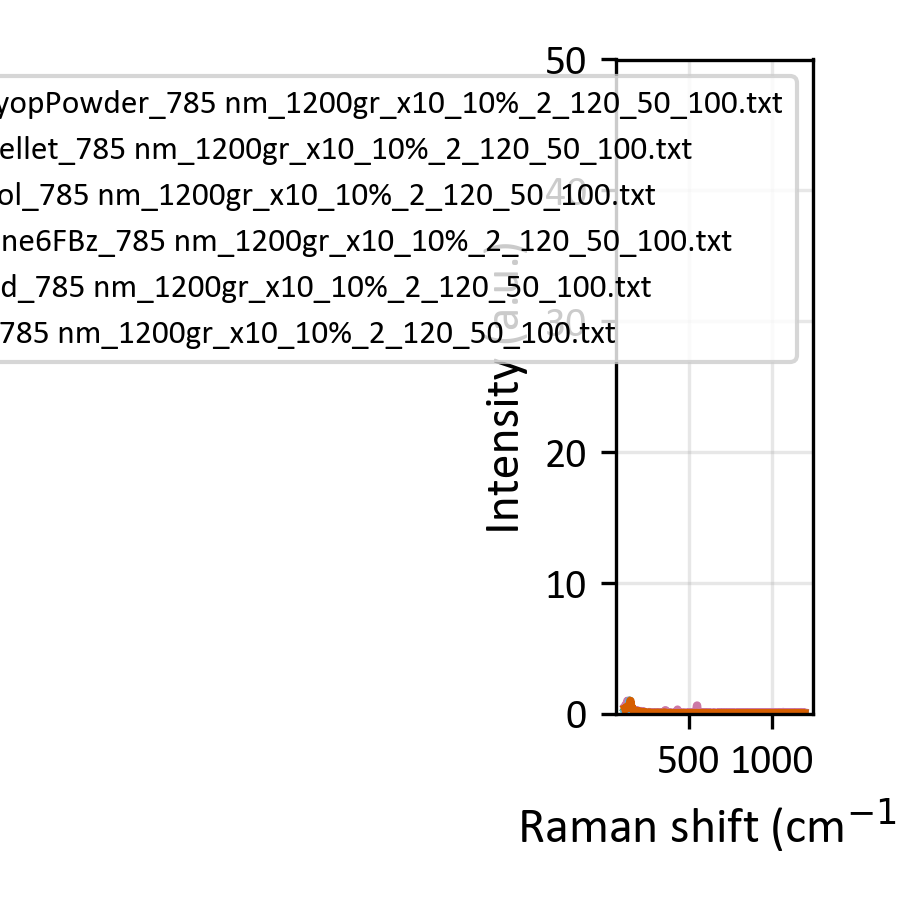

In [45]:
# Spectra from folder: 20260402_CNT_F005_6FBz@P2 | Wavelength: 785 nm
Spec_785nm_20260402_CNT_F005_6FBzP2 = [
    "260402_F005_6FBZ@P2LyopPowder_785 nm_1200gr_x10_10%_2_120_50_100.txt",
    "260402_F005_6FBZ@P2Pellet_785 nm_1200gr_x10_10%_2_120_50_100.txt",
    "260402_F005_6FBZ@P2Sol_785 nm_1200gr_x10_10%_2_120_50_100.txt",
    "260402_Hexafluorobenzene6FBz_785 nm_1200gr_x10_10%_2_120_50_100.txt",
    "260402_P2ReferencePowd_785 nm_1200gr_x10_10%_2_120_50_100.txt",
    "260402_P2ReferenceSol_785 nm_1200gr_x10_10%_2_120_50_100.txt",
]

selected_spectra = Spec_785nm_20260402_CNT_F005_6FBzP2
selected_spectra = {name: raman_spectra[name] for name in selected_spectra if name in raman_spectra}
#selected_spectra = TrimSpectra(selected_spectra, xmin=800, xmax=2000)
selected_spectra = NormalizeSpectra(selected_spectra, xmin=0, xmax=10000, mode="M")


# Optional: Provide cleaner names for the legend based on the filenames
clean_labels = [
 
]

# Plot the final processed data
PlotRaman(
    spectra_dict=selected_spectra, 
    spectra_names=selected_spectra,
    custom_labels=None,
    offset_step=0.0,          # Shifts each spectrum up by 1.2 for easy stacking
    xmin=None,
    xmax=None,
    ymax=50
)

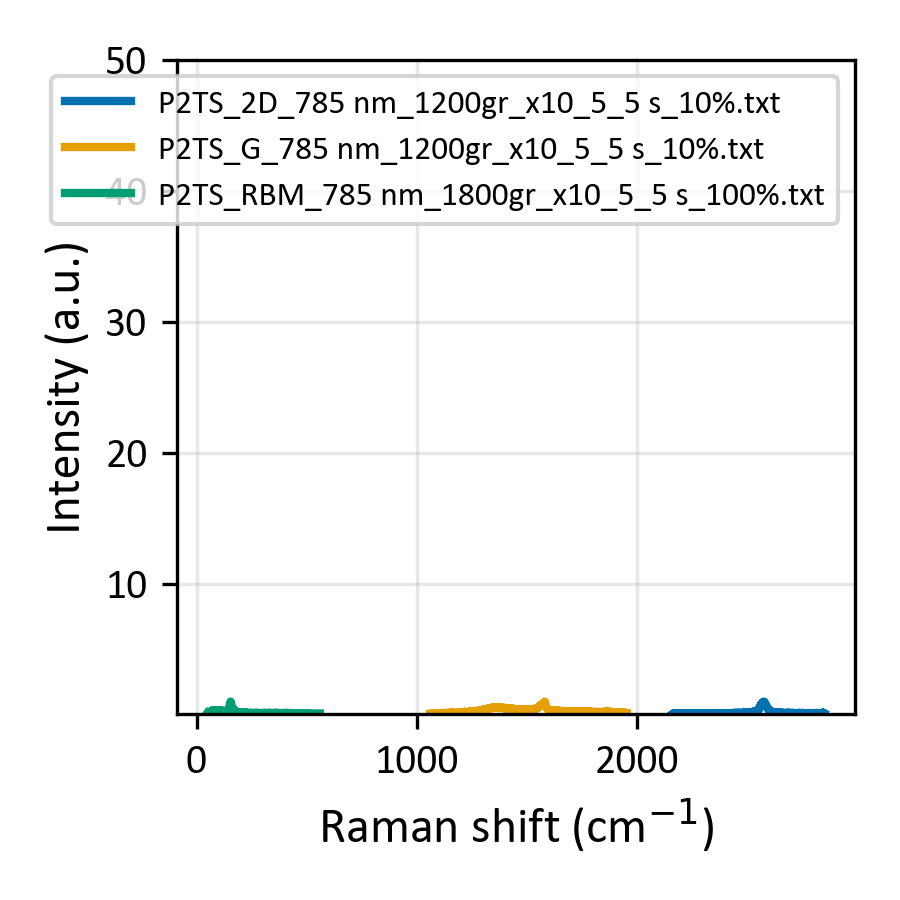

In [46]:
# Spectra from folder: 20260218_Ram_CNT_dispersions | Wavelength: 785 nm
Spec_785nm_20260218_Ram_CNT_dispersions = [
    "P2TS_2D_785 nm_1200gr_x10_5_5 s_10%.txt",
    "P2TS_G_785 nm_1200gr_x10_5_5 s_10%.txt",
    "P2TS_RBM_785 nm_1800gr_x10_5_5 s_100%.txt",
]

selected_spectra = Spec_785nm_20260218_Ram_CNT_dispersions
selected_spectra = {name: raman_spectra[name] for name in selected_spectra if name in raman_spectra}
#selected_spectra = TrimSpectra(selected_spectra, xmin=800, xmax=2000)
selected_spectra = NormalizeSpectra(selected_spectra, xmin=0, xmax=10000, mode="M")


# Optional: Provide cleaner names for the legend based on the filenames
clean_labels = [
 
]

# Plot the final processed data
PlotRaman(
    spectra_dict=selected_spectra, 
    spectra_names=selected_spectra,
    custom_labels=None,
    offset_step=0.0,          # Shifts each spectrum up by 1.2 for easy stacking
    xmin=None,
    xmax=None,
    ymax=50
)

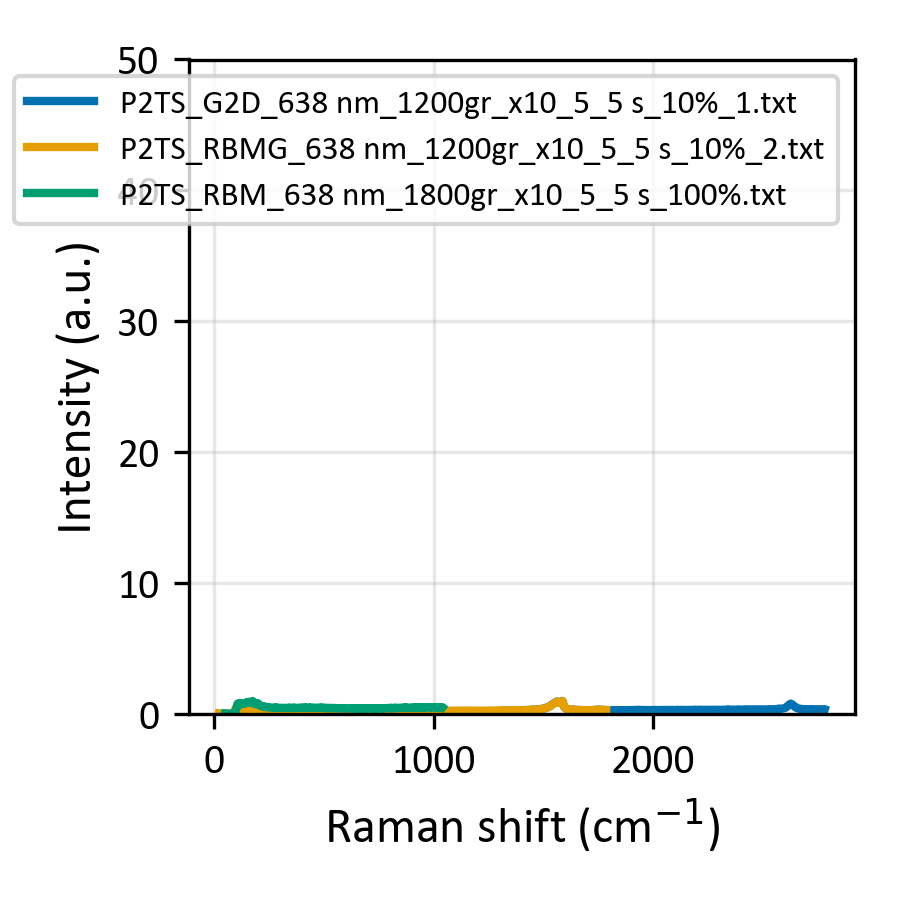

In [47]:
# Spectra from folder: 20260218_Ram_CNT_dispersions | Wavelength: 638 nm
Spec_638nm_20260218_Ram_CNT_dispersions = [
    #"NoPoTS_G2D_638 nm_1200gr_x10_5_5 s_10%.txt",
    #"NoPoTS_RBMG_638 nm_1200gr_x10_2_60 s_0_1%.txt",
    #"NoPoTS_RBM_638 nm_1800gr_x10_5_5 s_100%.txt",
    "P2TS_G2D_638 nm_1200gr_x10_5_5 s_10%_1.txt",
    "P2TS_RBMG_638 nm_1200gr_x10_5_5 s_10%_2.txt",
    "P2TS_RBM_638 nm_1800gr_x10_5_5 s_100%.txt",
]
selected_spectra = Spec_638nm_20260218_Ram_CNT_dispersions
selected_spectra = {name: raman_spectra[name] for name in selected_spectra if name in raman_spectra}
#selected_spectra = TrimSpectra(selected_spectra, xmin=800, xmax=2000)
selected_spectra = NormalizeSpectra(selected_spectra, xmin=0, xmax=10000, mode="M")


# Optional: Provide cleaner names for the legend based on the filenames
clean_labels = [
 
]

# Plot the final processed data
PlotRaman(
    spectra_dict=selected_spectra, 
    spectra_names=selected_spectra,
    custom_labels=None,
    offset_step=0.0,          # Shifts each spectrum up by 1.2 for easy stacking
    xmin=None,
    xmax=None,
    ymax=50
)

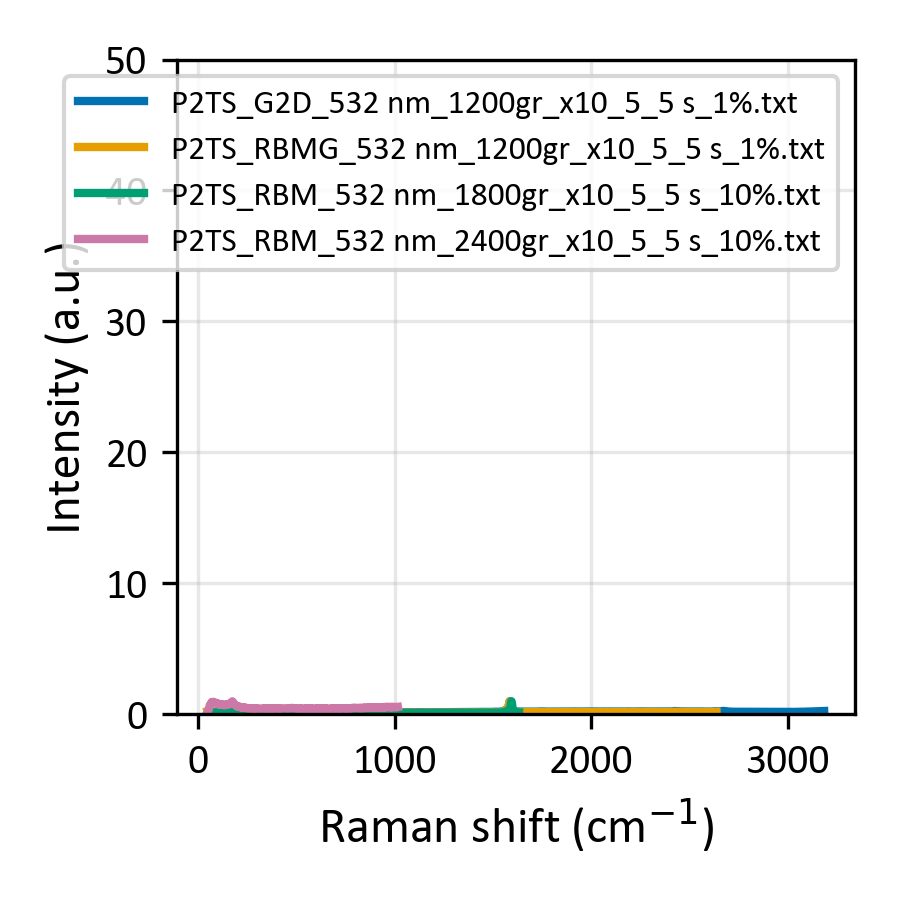

In [48]:
# Spectra from folder: 20260218_Ram_CNT_dispersions | Wavelength: 532 nm
Spec_532nm_20260218_Ram_CNT_dispersions = [
    #"NoPoTS_G2D_532 nm_1200gr_x10_5_5 s_1%.txt",
    #"NoPoTS_RBMG_532 nm_1200gr_x10_5_5 s_1%.txt",
    #"NoPoTS_RBM_532 nm_2400gr_x10_5_5 s_10%.txt",
    "P2TS_G2D_532 nm_1200gr_x10_5_5 s_1%.txt",
    "P2TS_RBMG_532 nm_1200gr_x10_5_5 s_1%.txt",
    "P2TS_RBM_532 nm_1800gr_x10_5_5 s_10%.txt",
    "P2TS_RBM_532 nm_2400gr_x10_5_5 s_10%.txt",
]
selected_spectra = Spec_532nm_20260218_Ram_CNT_dispersions
selected_spectra = {name: raman_spectra[name] for name in selected_spectra if name in raman_spectra}
#selected_spectra = TrimSpectra(selected_spectra, xmin=800, xmax=2000)
selected_spectra = NormalizeSpectra(selected_spectra, xmin=0, xmax=10000, mode="M")


# Optional: Provide cleaner names for the legend based on the filenames
clean_labels = [
 
]

# Plot the final processed data
PlotRaman(
    spectra_dict=selected_spectra, 
    spectra_names=selected_spectra,
    custom_labels=None,
    offset_step=0.0,          # Shifts each spectrum up by 1.2 for easy stacking
    xmin=None,
    xmax=None,
    ymax=50
)